# Final Project for 50.039 Deep Learning, Y2026
## Classification of Anomalous Malicious Packets
Submitted by:
- Keagan Teo (1007779)
- Cheng Mun Yun Valerie (1007879)

Imports

In [1]:
import joblib, json
import numpy as np
import xgboost as xgb

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

from helper_functions.model import NetworkAnomalyDetector, PacketsDataset
from helper_functions.preprocessing import one_hot_encode, get_preprocessor, load_data
from helper_functions.training import run_epoch, train, weighted_bce
from helper_functions.visualisation import plot_training_curves, plot_confusion_matrix, print_results, visualize_xgb_model

In [2]:
# Hyperparameters
LR = 1e-2
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 50
PATIENCE = 7

# Seed for reproducability
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


Reading the data

In [3]:
df = load_data("data/UNSW-NB15_1.csv")

/home/ubuntu/stoopidterm6/deeplearning/deeplearningsutd/helper_functions/preprocessing.py:78: DtypeWarning: Columns (1,3,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


### Feature engineering:

#### Dropping features
- "srcip" and "dstip" are raw ip addresses that won't generalize across datasets. Behavioral patterns from IPs are already captured by the ct_ features
- "stime" and "ltime" are absolute timestamps of the packet and carries no signal on whether traffic is malicious
- "stcpb" and "dtcpb" source and destination TCP base sequence number is randomly initialized and does not help with categorization
- "sport" and "dsport" are raw port numbers and service and protocol that can be deduced from port numbers are already captured in "proto" and "service" features
- "attack_cat" is an extension of a label and should not be included in the training data

In [4]:
df.drop(["srcip", "dstip", "stime", "ltime", "stcpb", "dtcpb", "sport", "dsport", "attack_cat"], axis=1, inplace=True)

#### One Hot Encoding columns with non-numerical data:
1. "proto" - protocol of the packet (tcp, udp, etc.)
2. "state" - state of the packet
3. "service" - service of the packet (ftp, http, smtp, etc.)

In [5]:
df_ohe = one_hot_encode(df, columns=['proto_group', 'state', 'service'])

#### Training/validation/test split

We split before normalizing so that we are able to calculate the averages of only the training set, and apply the transformations to the test and validation sets to prevent information leakage
- `stratify` used to ensure that the training/validation/test datasets will have an equal proportion of class labels as the original dataset. This is especially important for anormaly detection where there is a heavy class imbalance

In [6]:
# Remove labels before processing data
y = df_ohe.pop("label").values.astype(np.float32)
X = df_ohe

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 560000 | Val: 70000 | Test: 70000


#### Normalizing numerical columns

Different columns need to be handled differently based on what information they represent and the skewedness of their data.
- `Log + StandardScalar` - for columns that are heavily skewed to the right
- `MixMaxScalar` - for columns that we know the hard boundaries for
- `Clip + Log + StandardScalar` - for columns that have extreme values that are deemed to be noise and contribute in no meaningful way to training
- `StandardScalar` - for columns that already have a roughly normal distribution

In [8]:
preprocessor = get_preprocessor()
# Fit on train only, transform all splits
X_train = preprocessor.fit_transform(X_train).astype(np.float32)
X_val = preprocessor.transform(X_val).astype(np.float32)
X_test = preprocessor.transform(X_test).astype(np.float32)

In [9]:
INPUT_DIM = X_train.shape[1]
print(f"Input dimension after preprocessing: {INPUT_DIM}")

Input dimension after preprocessing: 73


### DataLoader

DataLoaders

In [10]:
train_dataset = PacketsDataset(X_train, y_train)
val_dataset = PacketsDataset(X_val,   y_val)
test_dataset = PacketsDataset(X_test,  y_test)

# Changed batch_size from 32 -> 512 due to increase in dataset sample size (TODO: see if we wanna change it back later)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

### Model 

Some things about our model:
- Uses He initialization for all Linear layers
- Applies a Linear -> BatchNorm -> ReLU -> Dropout for all hidden layers

In [11]:
model = NetworkAnomalyDetector(input_dim=INPUT_DIM, dropout_p=0.3).to(DEVICE)
print(model)
print(f"\nTrainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

NetworkAnomalyDetector(
  (network): Sequential(
    (0): Linear(in_features=73, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.3, inplace=False)
    (16): Linear(in_features=32, out_features=1, bias=True)
    (17): Sigmoid()
  )
)

Trainable parameters: 63,169


#### Loss, Optimizer, Scheduler

**Loss**: Weighted BCE — up-weights the minority malicious class by `n_benign / n_malicious` to counteract class imbalance.

In [12]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
raw_ratio = n_neg / n_pos

# in case of balanced dataset, penalize misclassification of malicious packets more, since a false negative is far more costly
pos_weight_value = max(1.5, raw_ratio)

pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)

print(f"pos_weight: {pos_weight.item():.2f}  (benign={n_neg:,}, malicious={n_pos:,})")

loss_func = lambda pred, target: weighted_bce(pred, target, pos_weight)

pos_weight: 30.51  (benign=542,228, malicious=17,772)


**Optimiser**: Adam with L2 weight decay.\
**Scheduler**: `ReduceLROnPlateau` halves the LR when val loss stagnates.

In [13]:
# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler (reduce LR when validation loss plateaus)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

#### Training the Model
>
> ❗️ Skip this part if you want to reload a trained model's weights
>

In [32]:
history, model = train(model, optimizer, scheduler, train_loader, val_loader, loss_func, DEVICE, NUM_EPOCHS, PATIENCE, verbose=True)

Epoch [001/50]  Train Loss: 0.0735  |  Val Loss: 0.0356  |  Val F1: 0.8972  |  Val AUC: 0.9991
  ✓  New best val loss: 0.0356
Epoch [002/50]  Train Loss: 0.0491  |  Val Loss: 0.0685  |  Val F1: 0.7514  |  Val AUC: 0.9982
Epoch [003/50]  Train Loss: 0.0507  |  Val Loss: 0.0376  |  Val F1: 0.8861  |  Val AUC: 0.9992
Epoch [004/50]  Train Loss: 0.0470  |  Val Loss: 0.0586  |  Val F1: 0.8817  |  Val AUC: 0.9955
Epoch [005/50]  Train Loss: 0.0514  |  Val Loss: 0.0456  |  Val F1: 0.8876  |  Val AUC: 0.9974
Epoch [006/50]  Train Loss: 0.0429  |  Val Loss: 0.0338  |  Val F1: 0.9078  |  Val AUC: 0.9992
  ✓  New best val loss: 0.0338
Epoch [007/50]  Train Loss: 0.0425  |  Val Loss: 0.0371  |  Val F1: 0.8899  |  Val AUC: 0.9993
Epoch [008/50]  Train Loss: 0.0405  |  Val Loss: 0.0313  |  Val F1: 0.9036  |  Val AUC: 0.9994
  ✓  New best val loss: 0.0313
Epoch [009/50]  Train Loss: 0.0412  |  Val Loss: 0.0337  |  Val F1: 0.8940  |  Val AUC: 0.9993
Epoch [010/50]  Train Loss: 0.0405  |  Val Loss: 0.0

Saving the model

In [33]:
torch.save(model.state_dict(), 'saved_models/model_before_tuning.pth')

#### Validation Set Evaluation

For reproducibility, load the model from save file

In [34]:
model = NetworkAnomalyDetector(input_dim=INPUT_DIM, dropout_p=0.3).to(DEVICE)
model.load_state_dict(torch.load("saved_models/model_before_tuning.pth"))
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

=== Validation Set Results ===
Loss      : 0.0255
Accuracy  : 0.9944
Precision : 0.8510
Recall    : 1.0000
F1        : 0.9195
ROC-AUC   : 0.9996


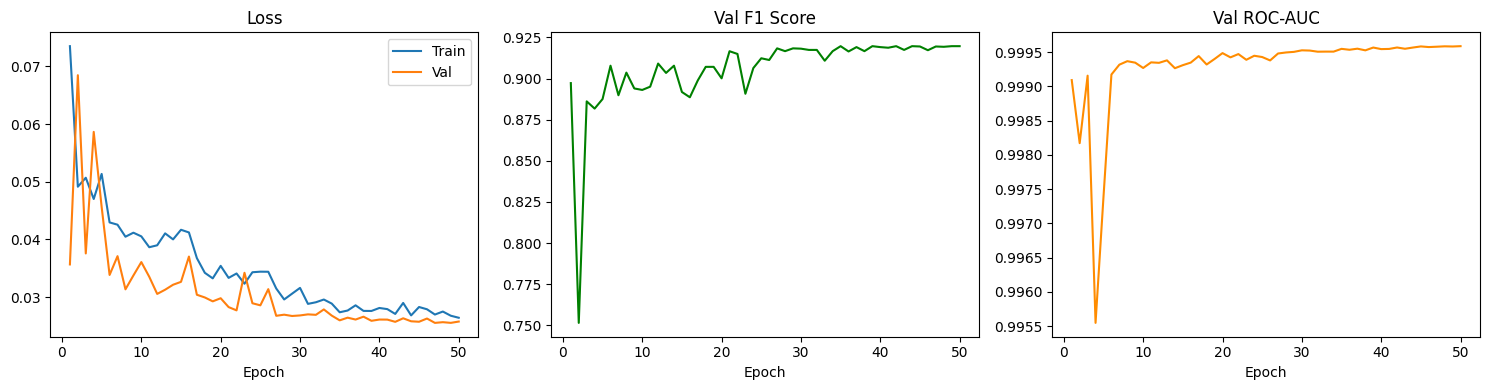

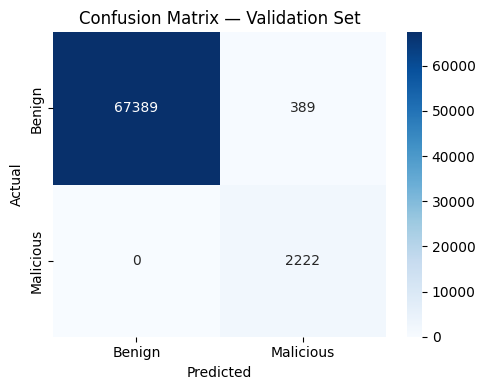

In [35]:
val_stats = run_epoch(model=model, optimizer=optimizer, data_loader=val_loader, loss_func=loss_func, device=DEVICE, training=False)
preds_bin = (val_stats['probs'] >= 0.5).astype(int)

print_results(val_stats, preds_bin, "=== Validation Set Results ===")
plot_training_curves(history)
plot_confusion_matrix(val_stats, preds_bin, 'Confusion Matrix — Validation Set')

#### Hyperparameter Tuning

After running `tuning.py` to obtain the best set of hyperparameters, we run the following cells for validation.

In [38]:
with open("tuning/best_params.json", "r") as f:
    best_params = json.load(f)["params"]

model = NetworkAnomalyDetector(input_dim=INPUT_DIM, dropout_p=best_params["dropout_p"]).to(DEVICE)
model.load_state_dict(torch.load('tuning/best_model.pth'))

optimizer = torch.optim.Adam(model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])

Evaluation

=== Validation Set Results ===
Loss      : 0.0225
Accuracy  : 0.9945
Precision : 0.8530
Recall    : 1.0000
F1        : 0.9207
ROC-AUC   : 0.9997


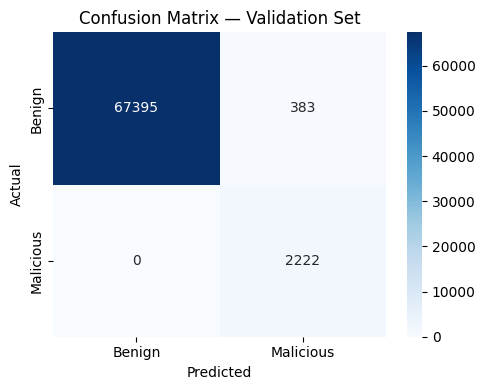

In [39]:
val_stats = run_epoch(model=model, optimizer=optimizer, data_loader=val_loader, loss_func=loss_func, device=DEVICE, training=False)
preds_bin = (val_stats['probs'] >= 0.5).astype(int)

print_results(val_stats, preds_bin, "=== Validation Set Results ===")
plot_confusion_matrix(val_stats, preds_bin, 'Confusion Matrix — Validation Set')

#### Test Set Evaluation

=== Test Set Results ===
Loss      : 0.0224
Accuracy  : 0.9948
Precision : 0.8585
Recall    : 1.0000
F1        : 0.9239
ROC-AUC   : 0.9998


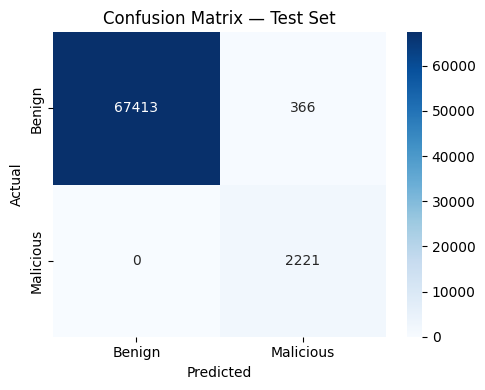

In [40]:
test_stats = run_epoch(model=model, optimizer=optimizer, data_loader=test_loader, loss_func=loss_func, device=DEVICE, training=False)
preds_bin = (test_stats['probs'] >= 0.5).astype(int)

print_results(test_stats, preds_bin, "=== Test Set Results ===")
plot_confusion_matrix(test_stats, preds_bin, 'Confusion Matrix — Test Set')

#### Comparison with State of the Art models

XGBoost

In [14]:
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Loss      : 0.0078
Accuracy  : 0.9976
Precision : 0.9605
Recall    : 0.9631
F1        : 0.9618
ROC-AUC   : 0.9997


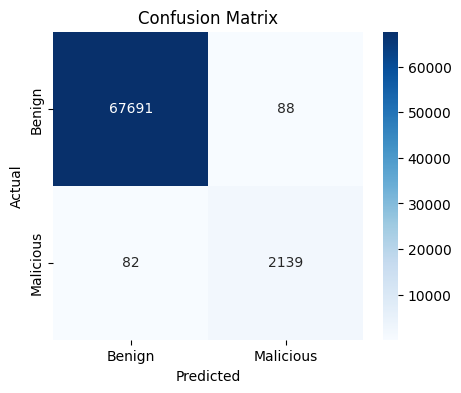

In [15]:
y_pred = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]
visualize_xgb_model(y_test, y_pred, y_pred_prob)